# <p align = "center" > Set Up Everything for MD Run </p>

<details open>
<summary> <ins> <strong> Tasks </strong> </ins>  </summary>

- Convert PDB into GRO -> Create topology

- Define Simulation Box

- Populate with Waters

- Populate with Ions

- Energy Minimization

- NVT Equillibration

- NPT Equillibration

</details>



In [2]:
import os

print( os.getcwd())
os.chdir( "../../../../data/md/01-gromacs_input" )
print( os.getcwd())

/home/alex/Documents/xaidar/notebooks/tasks/ev2a/md
/home/alex/Documents/xaidar/data/md/01-gromacs_input


In [3]:
import pandas as pd

## Generating a topology

<details open>
<summary> Generated Files: </summary>

* The topology for the molecule (`topol.top`)

* A position restraint file (`posre.itp`)

* A post-processed structure file (`A0926a_processed.gro`)

</details>

In [15]:
!gmx pdb2gmx -f ../00-input_pdb/A0926a_processed.pdb -o A0926a_processed.gro -water tip3p -ff "charmm27"

             :-) GROMACS - gmx pdb2gmx, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [16]:
# This does not work, the 
# !gmx pdb2gmx -f A0926a_processed.pdb -o A0926a_processed.gro -p topol.top -i A0926a_prot.itp -water tip3p -ff charmm27

## Defining the simulation box

<details open>
<summary> Generated Files: </summary>

* A post-processed structure file with relocated coordinates (`A0926a_newbox.gro`)

</details>

In [17]:
!gmx editconf -f A0926a_processed.gro -o A0926a_newbox.gro -c -d 1.0 -bt dodecahedron

             :-) GROMACS - gmx editconf, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff           

## Filling the box with water

<details open>
<summary> Generated Files: </summary>

* A post-processed structure file with water molecules included (`A0926a_solv.gro`)

</details>

In [18]:
!gmx solvate -cp A0926a_newbox.gro -cs spc216.gro -o A0926a_solv.gro -p topol.top

             :-) GROMACS - gmx solvate, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

# Adding Ions

<details open>
<summary> Generated Files: </summary>

* An initially empty file to allow generation of .tpr file (`ions.mdp`)

* Create file with instructions to alter water molecules into ions (`ions.tpr`)

* A post-processed structure file with water molecules and ions included (`A0926a_solv_ions.gro`)

</details>

In [19]:
!touch ions.mdp

In [20]:
!gmx grompp -f ions.mdp -c A0926a_solv.gro -p topol.top -o ions.tpr

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [21]:
!printf "SOL\n" | gmx genion -s ions.tpr -o A0926a_solv_ions.gro -conc 0.15 -p \
topol.top -pname NA -nname CL -neutral

              :-) GROMACS - gmx genion, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

# <ins> Energy minimisation </ins>

<details open>
<summary> Generated Files: </summary>

* Created a md Parameter file based off of the Gromacs tutorial, with information of the set up to perform a basic energy minimization (`emin-charmm.mdp`)

* Create binary file with concatenated instructions to minimize positions based on potential energy (`em.tpr`)

* A post-processed structure file with water molecules and ions included (`em.gro`)

* Energy Files (`em.edr`)

* High-precission trajectory files (`emd.trr`)

* Logs file (`em.log`)

* Energy Analysis File (`em-potential.xvg`)

</details>

In [23]:
!gmx grompp -f ../gromacs_mdp/emin-charmm.mdp -c A0926a_solv_ions.gro -p topol.top -o em.tpr

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# Performing the energy Minimization. All gmx mdrun commands will be run in a tmux shell terminal instead of interactively in the notebook
# !gmx mdrun -deffnm em -ntmpi 1 -ntomp 1
# -v try not using -v

## Analysis - Energy minimisation 

- Look at final overall potential energy and Maximum

    - Rule of Thumb

        - Maximum force (Fmax) of one atom < 1 000 kJ/(mol nm)

        - Overall force ~ 100 000 kJ/mol

- Look at evolution of overall potential energy of the system



In [31]:
# Final Results

!tail -6 em.log

Steepest Descents converged to Fmax < 1000 in 327 steps
Potential Energy  = -2.6411431e+05
Maximum force     =  9.9114679e+02 on atom 307
Norm of force     =  3.5905554e+01
Finished mdrun on rank 0 Fri Feb  6 16:50:01 2026



In [28]:
!printf "Potential\n0\n" | gmx energy -f em.edr -o ../02-gromacs_output/em-potential.xvg -xvg none

              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

<Axes: xlabel='step'>

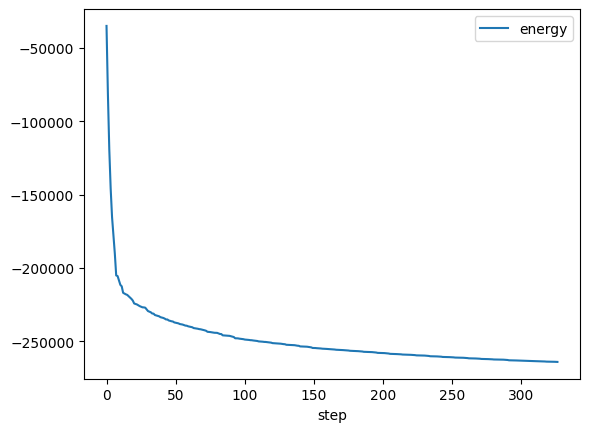

In [29]:
df = pd.read_csv('../02-gromacs_output/em-potential.xvg', sep='\\s+', header=None, names=['step','energy'])
df.plot('step')

# <ins> Equilibration run - temperature (NVT) </ins>

<details open>
<summary> Generated Files: </summary>

* Created a md Parameter file based off of the Gromacs tutorial, with information of the set up to perform a basic NVT Equillibration (`nvt-charmm.mdp`)

* Create binary file with concatenated instructions to equillibrate positions with thermostat (`nvt.tpr`)

* A post-processed structure file with water molecules and ions included (`nvt.gro`)

* Energy Files (`nvt.edr`)

* High-precission trajectory files (`nvt.trr`)

* Logs file (`nvt.log`)

* Check point that contains initial velocities (`nvt.cpt`)

* Energy Analysis File (`nvt-temp.xvg`)

</details>

In [32]:
!gmx grompp -f ../gromacs_mdp/nvt-charmm.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr 

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# !gmx mdrun -ntmpi 1 -ntomp 8 -deffnm nvt

## Analysis - NVT Equilibration 

Goal:

- Identify if the temperature was kept stable with the thermostat while the overall potential energy decreases and stabilized 

In [34]:
!echo "Temperature" | gmx energy -f nvt.edr -o ../02-gromacs_output/nvt-temp.xvg -xvg none -b 20

              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

<Axes: xlabel='time'>

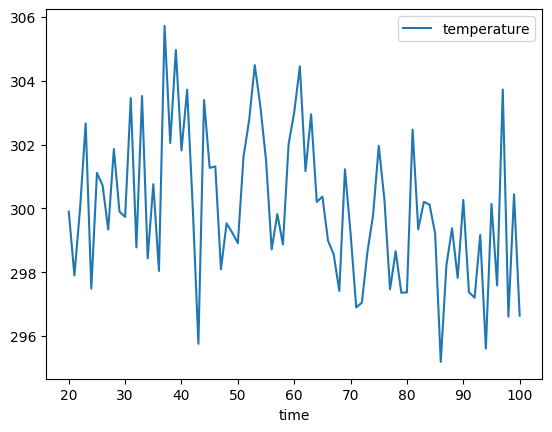

In [36]:
df = pd.read_csv('../02-gromacs_output/nvt-temp.xvg', sep='\\s+', header=None, names=['time','temperature'])
df.plot('time')

# <ins> Equilibration run - pressure (NPT) </ins>

<details open>
<summary> Generated Files: </summary>

* Created a md Parameter file based off of the Gromacs tutorial, with information of the set up to perform a basic NVT Equillibration (`npt-charmm.mdp`)

* Create binary file with concatenated instructions to equillibrate positions with thermostat (`npt.tpr`)

* A post-processed structure file with water molecules and ions included (`npt.gro`)

* Energy Files (`npt.edr`)

* High-precission trajectory files (`npt.trr`)

* Logs file (`npt.log`)

* Check point that contains initial velocities (`npt.cpt`)

* Energy Analysis File (`npt-pressure.xvg`, `npt-density.xvg` )

</details>

In [37]:
!gmx grompp -f ../gromacs_mdp/npt-charmm.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr      

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# !gmx mdrun -ntmpi 1 -ntomp 8 -deffnm npt

## Analysis - NPT Equilibration 

- ### Pressure

Goal:

- Identify if the pressure / density was kept stable with the thermostat while the overall potential energy decreases and stabilized 

In [45]:
!echo "Pressure" | gmx energy -f npt.edr -o ../02-gromacs_output/npt-pressure.xvg -xvg none

              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

<Axes: xlabel='time'>

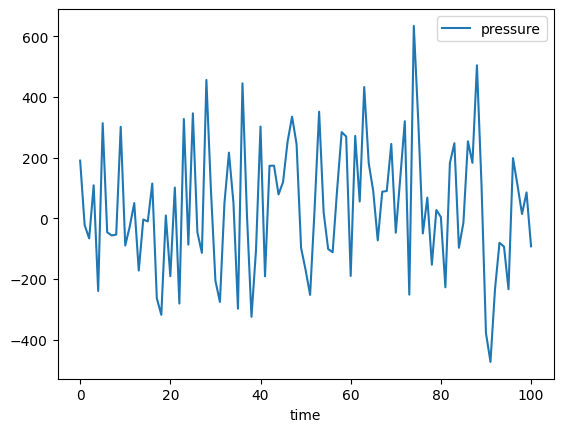

In [46]:
df = pd.read_csv('../02-gromacs_output/npt-pressure.xvg', sep='\\s+', header=None, names=['time','pressure'])
df.plot('time')

- ### Density

In [47]:
!echo "Density" | gmx energy -f npt.edr -o ../02-gromacs_output/npt-density.xvg -xvg none

              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

<Axes: xlabel='time'>

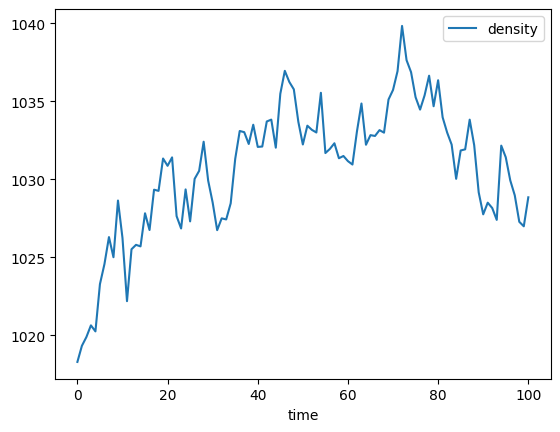

In [48]:
df = pd.read_csv('../02-gromacs_output/npt-density.xvg', sep='\\s+', header=None, names=['time','density'])
df.plot('time')

# <ins> The "production" run </ins>

In [44]:
!gmx grompp -f ../gromacs_mdp/md-charmm.mdp -c npt.gro -t npt.cpt -p topol.top -o md.tpr

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
!gmx mdrun -ntmpi 1 -ntomp 8 -deffnm md 

## Analysis - "Production" Run

- ### Periodic Boundary Conditions Processing

In [ ]:
# Make the Protein Whole (fix broken bonds)
!printf "1\n1\n" | gmx trjconv -s md.tpr -f md.xtc -o md_whole.xtc -pbc whole

In [4]:
# Center the Protein 
!printf "1\n1\n" | gmx trjconv -s md.tpr -f md_whole.xtc -o md_center.xtc -center -pbc mol

             :-) GROMACS - gmx trjconv, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

In [ ]:
# Fit to a reference -> prevent tumbling and rotation
!printf "1\n1\n" | gmx trjconv -f md_center.xtc -s md.tpr -fit rot+trans -o md_final.xtc

In [ ]:
gmx trjconv -f md_final.xtc -s md.tpr -o output.gro

In [9]:
print( os.getcwd())

/home/alex/Documents/xaidar/data/md/01-gromacs_input


# Save the Result as a movie

In [ ]:
# Save Frames in Pymol
# !mpng frame_
get movie_fps
set movie_fps, 60 # slower
smooth all, 5, 5 # 
movie.produce my_movie.mp4, quality=90

In [ ]:
# Convert Frames into a movie with ffmpeg
ffmpeg -framerate 60 -i frame_%04d.png -c:v libx264 -pix_fmt yuv420p output.mp4

In [ ]:
D:\OneDrive - University of Edinburgh\Documents

## Check the minimum image convention

In [ ]:
!printf "1\n" | gmx mindist -s md.tpr -f md_center.xtc -pi -od ../02-gromacs_output/mindist.xvg 

             :-) GROMACS - gmx mindist, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

## Evaluate structural stability with RMSD

Look at alpha-carbons

In [5]:
!printf "4\n1\n" | gmx rms -s em.tpr -f md_final.xtc -o ../02-gromacs_output/rmsd_xray.xvg -tu ns -xvg none

               :-) GROMACS - gmx rms, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Te

<Axes: xlabel='time'>

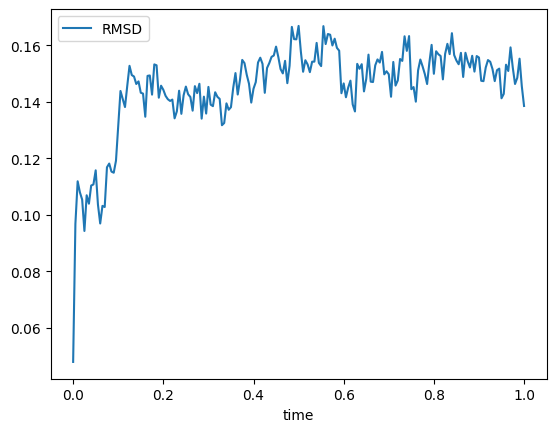

In [6]:
df = pd.read_csv('../02-gromacs_output/rmsd_xray.xvg', sep='\\s+', header=None, names=['time','RMSD'])
df.plot('time')

## Measure compactness with radius of gyration

In [7]:
!echo "1" | gmx gyrate -f md_center.xtc -s md.tpr -o ../02-gromacs_output/gyrate.xvg -xvg none

              :-) GROMACS - gmx gyrate, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

<Axes: xlabel='time'>

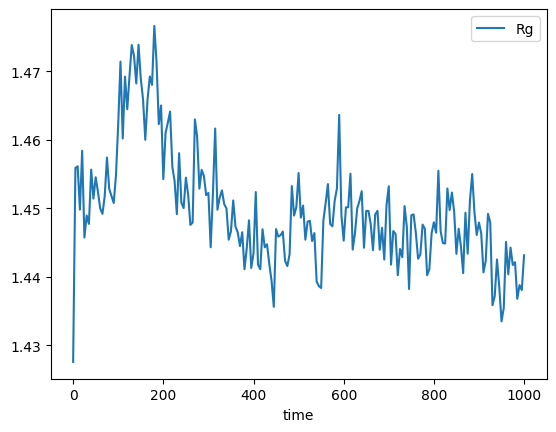

In [8]:
df = pd.read_csv('../02-gromacs_output/gyrate.xvg', sep='\\s+', header=None, names=['time','Rg'], usecols=[0, 1])
df.plot('time')